Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

RESULTS = Path("../results")
FINAL = Path("../results_final")
PLOTS = Path("../plots")
PLOTS.mkdir(exist_ok=True)

METHODS = ["random", "hillclimb", "llm_oneshot", "llm_loop"]
LABELS  = ["Random", "Hill-climb", "LLM one-shot", "LLM + feedback"]
COLORS  = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

Load raw results and sanity-check row counts / seeds / contamination

In [13]:
raw = {m: pd.read_parquet(RESULTS / f"search_{m}.parquet") for m in METHODS}
baselines = pd.read_parquet(RESULTS / "baselines.parquet")

print(f"{'method':<14}{'rows':>6}{'benches':>9}{'seeds':>10}{'evals/bench':>14}")
for m, df in raw.items():
    n_bench = df["bench"].nunique()
    seeds = sorted(df["seed"].unique().tolist())
    per_bench_evals = df.groupby("bench")["eval_idx"].max()
    uniform = per_bench_evals.nunique() == 1
    print(f"{m:<14}{len(df):>6}{n_bench:>9}{str(seeds):>10}{'OK' if uniform else str(per_bench_evals.to_dict()):>14}")

assert len(set(df["bench"].nunique() for df in raw.values())) == 1, "benchmark count mismatch across methods"
for m, df in raw.items():
    dup = df.duplicated(subset=["bench", "eval_idx"]).sum()
    if dup:
        print(f"WARNING: {m} has {dup} duplicate (bench, eval_idx) rows — likely leftover data from an old run")
    max_evals = df.groupby("bench")["eval_idx"].max()
    if (max_evals != 60).any():
        print(f"WARNING: {m} does not have exactly 60 evals for every benchmark:\n{max_evals[max_evals != 60]}")

method          rows  benches     seeds   evals/bench
random           720       12       [0]            OK
hillclimb        720       12       [0]            OK
llm_oneshot      720       12       [0]            OK
llm_loop         720       12       [0]            OK


Baseline pivot

In [14]:
base = (baselines
        .dropna(subset=["instr"])
        .drop_duplicates(["bench", "level"], keep="last")
        .pivot(index="bench", columns="level", values="instr"))
base

level,O2,O3
bench,,
2mm,6065221,6001963
3mm,6116066,6018002
atax,5986321,5983676
bicg,5992596,5992581
correlation,6044075,6019248
covariance,6036591,6015133
gemm,6049471,6073667
gesummv,5983479,5983467
heat-3d,6410347,6335357


Best-per-benchmark + main comparison table

In [15]:
def geomean(x):
    x = np.asarray(x, dtype=float)
    return float(np.exp(np.log(x).mean()))

bests = {}
for m, df in raw.items():
    bests[m] = df.dropna(subset=["instr"]).groupby("bench")["instr"].min()

tbl = base.join(pd.DataFrame(bests))

for m in METHODS:
    tbl[f"{m}/O2"] = (tbl[m] / tbl["O2"]).round(3)

display_cols = ["O2", "O3"] + METHODS + [f"{m}/O2" for m in METHODS]
tbl_display = tbl[display_cols].copy()
for c in ["O2", "O3"] + METHODS:
    tbl_display[c] = tbl_display[c].map(lambda v: f"{int(v):,}")
tbl_display

,O2,O3,random,hillclimb,llm_oneshot,llm_loop,random/O2,hillclimb/O2,llm_oneshot/O2,llm_loop/O2
bench,,,,,,,,,,
2mm,"6,065,221","6,001,963","6,068,952","6,067,577","6,067,936","6,067,489",1.001,1.000,1.000,1.000
3mm,"6,116,066","6,018,002","6,120,745","6,119,980","6,119,992","6,119,880",1.001,1.001,1.001,1.001
atax,"5,986,321","5,983,676","5,987,274","5,985,833","5,985,362","5,985,370",1.000,1.000,1.000,1.000
bicg,"5,992,596","5,992,581","5,988,847","5,988,043","5,988,055","5,988,049",0.999,0.999,0.999,0.999
correlation,"6,044,075","6,019,248","6,063,906","6,056,460","6,060,471","6,060,450",1.003,1.002,1.003,1.003
covariance,"6,036,591","6,015,133","6,054,085","6,052,523","6,047,853","6,052,086",1.003,1.003,1.002,1.003
gemm,"6,049,471","6,073,667","6,083,203","6,043,208","6,048,798","6,081,720",1.006,0.999,1.000,1.005
gesummv,"5,983,479","5,983,467","5,981,419","5,980,706","5,980,718","5,980,284",1.000,1.000,1.000,0.999
heat-3d,"6,410,347","6,335,357","6,414,745","6,271,303","6,281,606","6,281,175",1.001,0.978,0.980,0.980


Geomeans and O3-beat counts

In [16]:
print("Geomean vs -O2 (above 1.0 = worse than -O2 on instruction count):")
for m, lbl in zip(METHODS, LABELS):
    g = geomean(tbl[m] / tbl["O2"])
    print(f"  {lbl:<16} {g:.3f}x")

print("\nBenchmarks where method beats -O3:")
for m, lbl in zip(METHODS, LABELS):
    beats = int((tbl[m] < tbl["O3"]).sum())
    print(f"  {lbl:<16} {beats}/{len(tbl)}")

llm1 = raw["llm_oneshot"]
valid_rate = llm1["passes"].ne("").mean()
mean_attempts = llm1.loc[llm1["passes"].ne(""), "llm_attempts"].mean()
print(f"\nLLM one-shot valid-proposal rate: {valid_rate:.0%}")
print(f"LLM one-shot mean attempts per accepted proposal: {mean_attempts:.2f}")

Geomean vs -O2 (above 1.0 = worse than -O2 on instruction count):
  Random           1.003x
  Hill-climb       0.996x
  LLM one-shot     0.997x
  LLM + feedback   1.001x

Benchmarks where method beats -O3:
  Random           3/12
  Hill-climb       6/12
  LLM one-shot     6/12
  LLM + feedback   4/12

LLM one-shot valid-proposal rate: 100%
LLM one-shot mean attempts per accepted proposal: 1.07


Headline figure (bar + convergence)

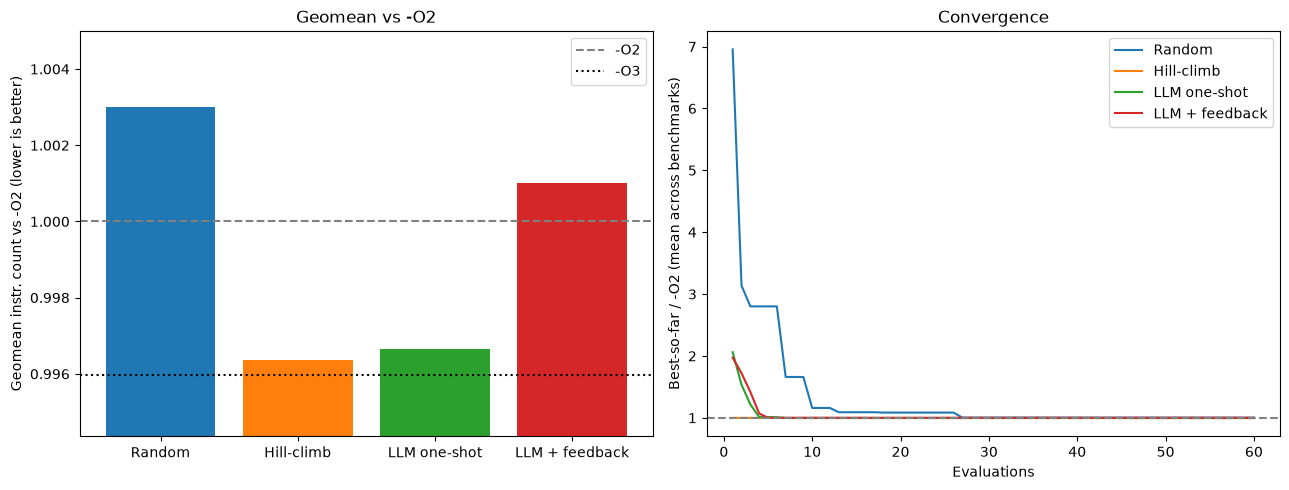

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

gms = [geomean(tbl[m] / tbl["O2"]) for m in METHODS]
ax1.bar(LABELS, gms, color=COLORS)
ax1.axhline(1.0, ls="--", c="gray", label="-O2")
o3_gm = geomean(tbl["O3"] / tbl["O2"])
ax1.axhline(o3_gm, ls=":", c="black", label="-O3")
ax1.set_ylabel("Geomean instr. count vs -O2 (lower is better)")
pad = 0.002
ax1.set_ylim(min(gms) - pad, max(gms) + pad)
ax1.legend()
ax1.set_title("Geomean vs -O2")

for m, lbl, c in zip(METHODS, LABELS, COLORS):
    df = raw[m].dropna(subset=["best_so_far"]).merge(
        base["O2"].rename("o2"), left_on="bench", right_index=True)
    df["rel"] = df["best_so_far"] / df["o2"]
    curve = df.groupby("eval_idx")["rel"].mean()
    ax2.plot(curve.index, curve.values, label=lbl, color=c)
ax2.axhline(1.0, ls="--", c="gray")
ax2.set_xlabel("Evaluations")
ax2.set_ylabel("Best-so-far / -O2 (mean across benchmarks)")
ax2.legend()
ax2.set_title("Convergence")

fig.tight_layout()
fig.savefig(PLOTS / "headline.png", dpi=150)
plt.show()

Per-benchmark win/loss detail

In [27]:
for m, lbl in zip(METHODS, LABELS):
    wins_o2 = tbl[tbl[m] < tbl["O2"]]
    wins_o3 = tbl[tbl[m] < tbl["O3"]]
    print(f"\n{lbl}:")
    print(f"  beats -O2 on: {list(wins_o2.index) if len(wins_o2) else 'none'}")
    print(f"  beats -O3 on: {list(wins_o3.index) if len(wins_o3) else 'none'}")


Random:
  beats -O2 on: ['bicg', 'gesummv', 'mvt']
  beats -O3 on: ['bicg', 'gesummv', 'mvt']

Hill-climb:
  beats -O2 on: ['atax', 'bicg', 'gemm', 'gesummv', 'heat-3d', 'jacobi-2d', 'mvt', 'seidel-2d']
  beats -O3 on: ['bicg', 'gemm', 'gesummv', 'heat-3d', 'mvt', 'seidel-2d']

LLM one-shot:
  beats -O2 on: ['atax', 'bicg', 'gemm', 'gesummv', 'heat-3d', 'jacobi-2d', 'mvt', 'seidel-2d']
  beats -O3 on: ['bicg', 'gemm', 'gesummv', 'heat-3d', 'mvt', 'seidel-2d']

LLM + feedback:
  beats -O2 on: ['atax', 'bicg', 'gesummv', 'heat-3d', 'mvt']
  beats -O3 on: ['bicg', 'gesummv', 'heat-3d', 'mvt']


Wall-clock validation

In [37]:
wc = pd.read_parquet(RESULTS / "wallclock_validation.parquet")
wc_display = wc[["bench", "o2_median", "tuned_median", "speedup"]].copy()
wc_display["o2_median"] = wc_display["o2_median"].map(lambda v: f"{v:.5f}s")
wc_display["tuned_median"] = wc_display["tuned_median"].map(lambda v: f"{v:.5f}s")
wc_display["speedup"] = wc_display["speedup"].map(lambda v: f"{v:.3f}x")
display(wc_display)

gm_wc = geomean(wc["speedup"])
print(f"\nGeomean wall-clock speedup vs -O2: {gm_wc:.3f}x")

,bench,o2_median,tuned_median,speedup
0,gemm,0.00869s,0.00944s,0.921x
1,2mm,0.01103s,0.01125s,0.980x
2,3mm,0.01022s,0.00996s,1.027x
3,atax,0.00789s,0.00990s,0.796x
4,bicg,0.00767s,0.00828s,0.925x
5,mvt,0.00858s,0.00767s,1.119x
6,gesummv,0.00764s,0.00760s,1.006x
7,jacobi-2d,0.00775s,0.00779s,0.995x
8,seidel-2d,0.01102s,0.01179s,0.935x
9,heat-3d,0.00788s,0.00797s,0.988x



Geomean wall-clock speedup vs -O2: 0.974x


Ablation table

In [38]:
try:
    llm_loop_h2 = pd.read_parquet(RESULTS / "search_llm_loop_h2.parquet")
    llm_loop_nofeat = pd.read_parquet(RESULTS / "search_llm_loop_nofeat.parquet")
    ablation_bench = ["gemm", "atax", "jacobi-2d", "correlation", "mvt"]

    def geomean_subset(df, benches):
        best = df.dropna(subset=["instr"]).groupby("bench")["instr"].min()
        b = base.loc[benches, "O2"]
        return geomean(b / best.loc[benches])

    rows = [
        ("LLM one-shot",       geomean_subset(raw["llm_oneshot"], ablation_bench)),
        ("LLM loop (h=8)",     geomean_subset(raw["llm_loop"], ablation_bench)),
        ("LLM loop (h=2)",     geomean_subset(llm_loop_h2, ablation_bench)),
        ("LLM loop (no feat)", geomean_subset(llm_loop_nofeat, ablation_bench)),
    ]
    ablation_df = pd.DataFrame(rows, columns=["variant", "geomean_vs_O2"])
    ablation_df["geomean_vs_O2"] = ablation_df["geomean_vs_O2"].round(3)
    display(ablation_df)
except FileNotFoundError as e:
    print(f"Ablation files not found ({e}) — skip, or rerun A1/A2/A3 on the fixed pipeline first")

,variant,geomean_vs_O2
0,LLM one-shot,1.000
1,LLM loop (h=8),0.995
2,LLM loop (h=2),0.999
3,LLM loop (no feat),0.999


Freeze clean results

In [40]:
import shutil

FINAL.mkdir(exist_ok=True)
for m in METHODS:
    shutil.copy(RESULTS / f"search_{m}.parquet", FINAL / f"search_{m}.parquet")
shutil.copy(RESULTS / "baselines.parquet", FINAL / "baselines.parquet")
shutil.copy(RESULTS / "wallclock_validation.parquet", FINAL / "wallclock_validation.parquet")
print("Frozen clean results to results_final/ (no _backup, no _latest duplicates)")

# print("\n--- Paste into README, replacing the old Results section ---\n")
print("| Method | Geomean vs O2 | Beats O3 |")
print("|---|---|---|")
for m, lbl in zip(METHODS, LABELS):
    g = geomean(tbl[m] / tbl["O2"])
    beats = int((tbl[m] < tbl["O3"]).sum())
    print(f"| {lbl} | {g:.3f}x | {beats}/12 |")
print(f"\nWall-clock geomean (hill-climb winners): {gm_wc:.3f}x")
print("Seeds: 0 (single seed — do not claim multiple seeds)")
print("Budget: 60 evaluations per benchmark, per method")

Frozen clean results to results_final/ (no _backup, no _latest duplicates)
| Method | Geomean vs O2 | Beats O3 |
|---|---|---|
| Random | 1.003x | 3/12 |
| Hill-climb | 0.996x | 6/12 |
| LLM one-shot | 0.997x | 6/12 |
| LLM + feedback | 1.001x | 4/12 |

Wall-clock geomean (hill-climb winners): 0.974x
Seeds: 0 (single seed — do not claim multiple seeds)
Budget: 60 evaluations per benchmark, per method
